In [1]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 


In [2]:
from sklearn.datasets import load_diabetes 
data = load_diabetes()

print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
X = data.data 
y = data.target 

In [4]:
X.shape

(442, 10)

In [5]:
y.shape

(442,)

In [9]:
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split 


X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state= 42)

lr = LinearRegression() 
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
lr.coef_

array([  37.90402135, -241.96436231,  542.42875852,  347.70384391,
       -931.48884588,  518.06227698,  163.41998299,  275.31790158,
        736.1988589 ,   48.67065743])

In [11]:
lr.intercept_

151.34560453985995

In [12]:
y_pred = lr.predict(X_test)

In [15]:
from sklearn.metrics import r2_score ,root_mean_squared_error

print("R2: ",r2_score(y_test,y_pred))
print("RMSE: ",root_mean_squared_error(y_test,y_pred))

R2:  0.4526027629719197
RMSE:  53.853445836765914


# Using Ridge(L2)

In [16]:
from sklearn.linear_model import Ridge 

rg = Ridge(alpha = 20) 

rg.fit(X_train,y_train)

,alpha,20
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [17]:
rg.coef_

array([ 10.57219448,  -0.76804924,  35.5244581 ,  26.53005481,
        10.21689642,   7.39808353, -21.87694961,  23.80755837,
        32.15847331,  22.3994501 ])

In [18]:
rg.intercept_

153.5280676803138

In [19]:
y_predi = rg.predict(X_test)

In [20]:
print("R2: ",r2_score(y_test,y_predi))
print("RMSE: ",root_mean_squared_error(y_test, y_predi))

R2:  0.09089832178968171
RMSE:  69.40143115231396


# For Non-Linear Quadratic Dataset

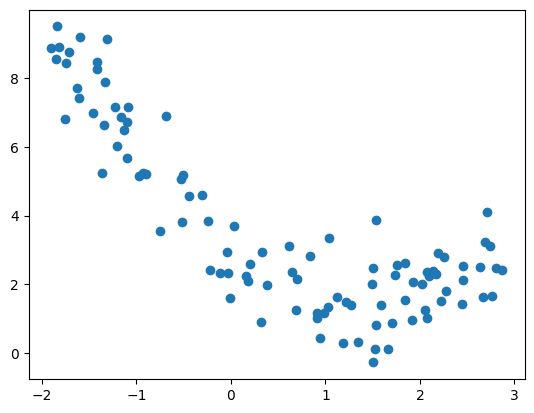

In [21]:


m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

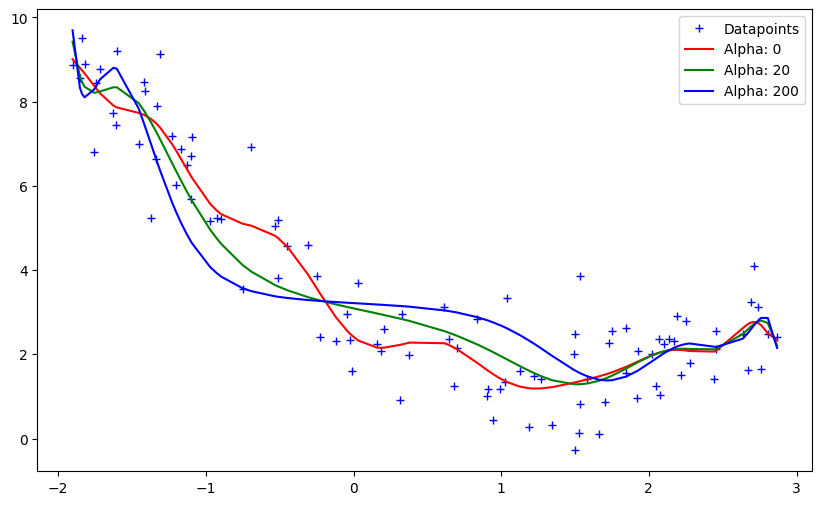

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

### The value of alpha 20 is preferrable here